In [56]:
# https://www.kaggle.com/datasets/hojjatk/mnist-dataset
# MNIST Dataset

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import struct
from array import array
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [58]:
data_path = r'D:\Documents\__NCFU\AI_methods-main\ai\MNIST Dataset'

In [59]:
def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        if magic != 2051:
            raise ValueError('Неверный magic number для файла изображений')
        rows, cols = struct.unpack(">II", f.read(8))
        images = np.fromfile(f, dtype=np.uint8).reshape(size, rows * cols)
    return images.astype('float32')

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError('Неверный magic number для файла меток')
        labels = np.fromfile(f, dtype=np.uint8)
    return labels.astype('int64')

In [60]:
print("Загрузка данных MNIST...")
X_train = load_mnist_images(os.path.join(data_path, 'train-images.idx3-ubyte'))
y_train = load_mnist_labels(os.path.join(data_path, 'train-labels.idx1-ubyte'))
X_test = load_mnist_images(os.path.join(data_path, 't10k-images.idx3-ubyte'))
y_test = load_mnist_labels(os.path.join(data_path, 't10k-labels.idx1-ubyte'))

Загрузка данных MNIST...


In [61]:
classes = [str(i) for i in range(10)]
print("Классы:", classes)

Классы: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [62]:
print("\nРазмер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("Количество классов:", len(np.unique(y_train)))


Размер обучающей выборки: (60000, 784)
Размер тестовой выборки: (10000, 784)
Количество классов: 10


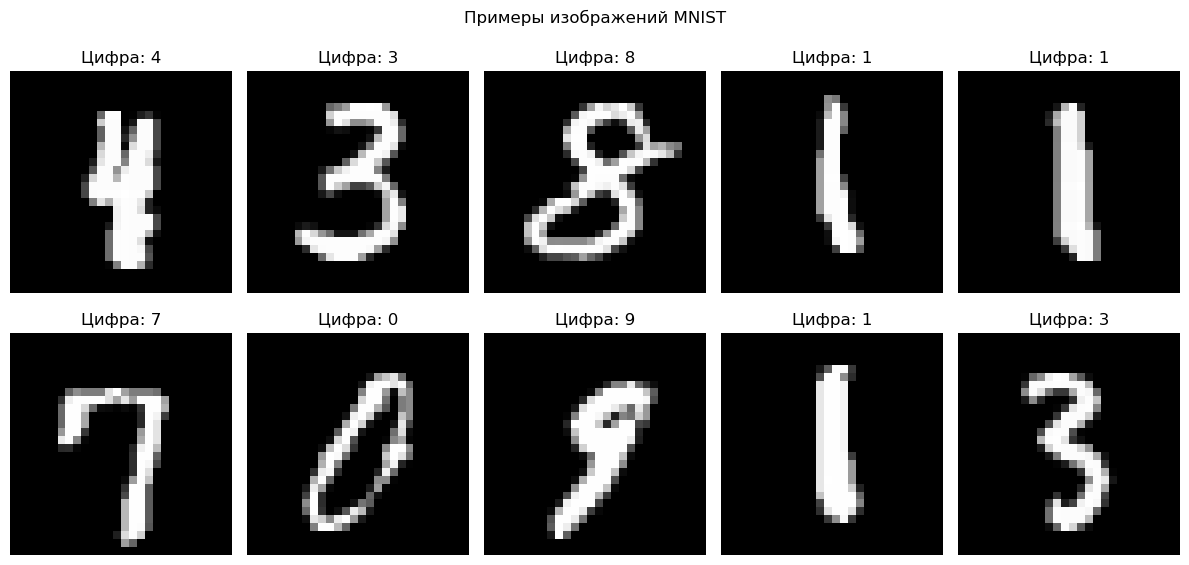

In [63]:
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    idx = np.random.randint(0, len(X_train))
    plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f'Цифра: {y_train[idx]}')
    plt.axis('off')
plt.suptitle('Примеры изображений MNIST')
plt.tight_layout()
plt.show()

In [64]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [65]:
X_train_tensor = torch.FloatTensor(X_train).view(-1, 1, 28, 28)
y_train_tensor = torch.LongTensor(y_train.astype(np.int64))
X_test_tensor = torch.FloatTensor(X_test).view(-1, 1, 28, 28)
y_test_tensor = torch.LongTensor(y_test.astype(np.int64))
print("\nФорма тензоров:", X_train_tensor.shape)


Форма тензоров: torch.Size([60000, 1, 28, 28])


In [66]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        
        # Первый сверточный блок
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # Уменьшили количество фильтров
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Второй сверточный блок
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # Уменьшили количество фильтров
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Полносвязные слои
        # После двух пулингов размер становится 28/2/2 = 7
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
        # Dropout для регуляризации
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        # Первый блок
        x = self.pool1(F.relu(self.conv1(x)))
        
        # Второй блок
        x = self.pool2(F.relu(self.conv2(x)))
        
        # Изменение формы
        x = x.view(-1, 32 * 7 * 7)
        
        # Полносвязные слои с Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [67]:
model = MNIST_CNN()
print("\nАрхитектура модели:")
print(model)


Архитектура модели:
MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [68]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")


Всего параметров: 206,922
Обучаемых параметров: 206,922


In [69]:
def generate_batches(X, y, batch_size=128):  # Увеличили batch size
    for i in range(0, X.shape[0], batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]
        yield X_batch, y_batch

In [70]:
BATCH_SIZE = 128  # Увеличили для скорости
NUM_EPOCHS = 5    # Уменьшили для теста
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [71]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

print("\nНачало обучения...")
for epoch in range(NUM_EPOCHS):
    # Обучение
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    num_batches = 0
    
    for X_batch, y_batch in generate_batches(X_train_tensor, y_train_tensor, BATCH_SIZE):
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        num_batches += 1
        
        if num_batches % 100 == 0:  # Прогресс каждые 100 батчей
            print(f'  Батч {num_batches}/{len(X_train_tensor)//BATCH_SIZE}, Loss: {loss.item():.4f}')
    
    train_loss = running_loss / num_batches
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Валидация на тестовой выборке
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    num_batches = 0
    
    with torch.no_grad():
        for X_batch, y_batch in generate_batches(X_test_tensor, y_test_tensor, BATCH_SIZE):
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
            num_batches += 1
    
    test_loss = test_loss / num_batches
    test_acc = 100 * correct / total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    print(f'\nЭпоха {epoch+1}/{NUM_EPOCHS}:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')


Начало обучения...
  Батч 100/468, Loss: 0.5734
  Батч 200/468, Loss: 0.2452
  Батч 300/468, Loss: 0.2427
  Батч 400/468, Loss: 0.1476

Эпоха 1/5:
  Train Loss: 0.3947, Train Acc: 88.22%
  Test Loss: 0.0922, Test Acc: 97.00%
  Батч 100/468, Loss: 0.1481
  Батч 200/468, Loss: 0.1747
  Батч 300/468, Loss: 0.1062
  Батч 400/468, Loss: 0.0443

Эпоха 2/5:
  Train Loss: 0.0996, Train Acc: 97.05%
  Test Loss: 0.0554, Test Acc: 98.10%
  Батч 100/468, Loss: 0.0983
  Батч 200/468, Loss: 0.1564
  Батч 300/468, Loss: 0.0796
  Батч 400/468, Loss: 0.0149

Эпоха 3/5:
  Train Loss: 0.0687, Train Acc: 97.95%
  Test Loss: 0.0449, Test Acc: 98.39%
  Батч 100/468, Loss: 0.1166
  Батч 200/468, Loss: 0.1102
  Батч 300/468, Loss: 0.1014
  Батч 400/468, Loss: 0.0248

Эпоха 4/5:
  Train Loss: 0.0541, Train Acc: 98.35%
  Test Loss: 0.0339, Test Acc: 98.84%
  Батч 100/468, Loss: 0.0224
  Батч 200/468, Loss: 0.1737
  Батч 300/468, Loss: 0.0442
  Батч 400/468, Loss: 0.0176

Эпоха 5/5:
  Train Loss: 0.0437, Train 

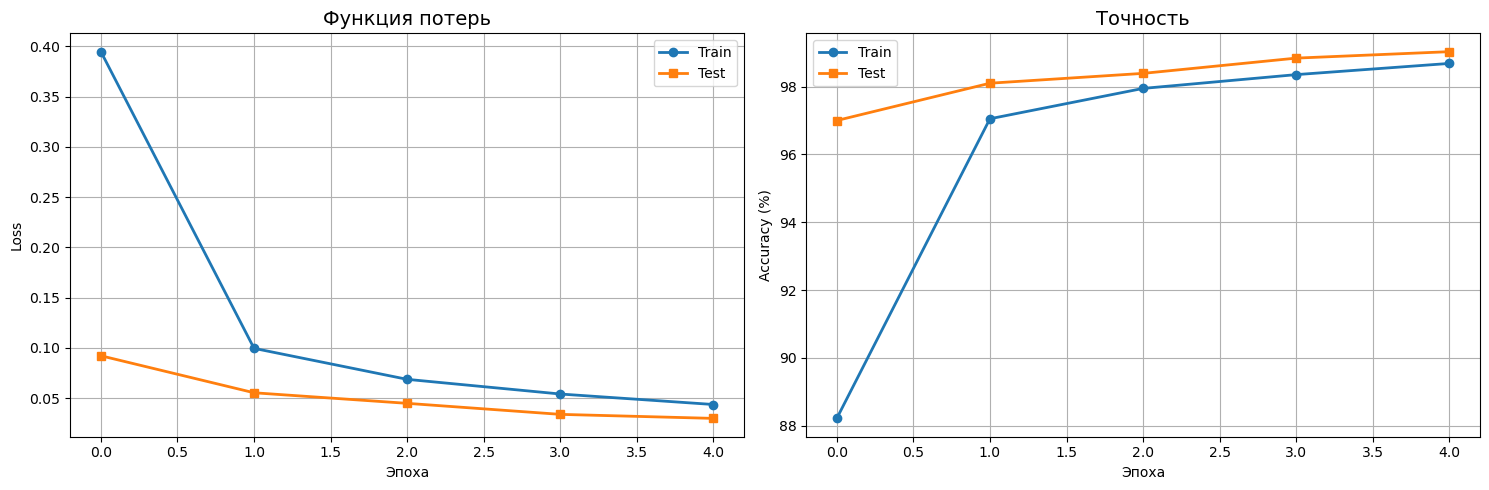

In [72]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train', linewidth=2, marker='o')
plt.plot(test_losses, label='Test', linewidth=2, marker='s')
plt.title('Функция потерь', fontsize=14)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train', linewidth=2, marker='o')
plt.plot(test_accuracies, label='Test', linewidth=2, marker='s')
plt.title('Точность', fontsize=14)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

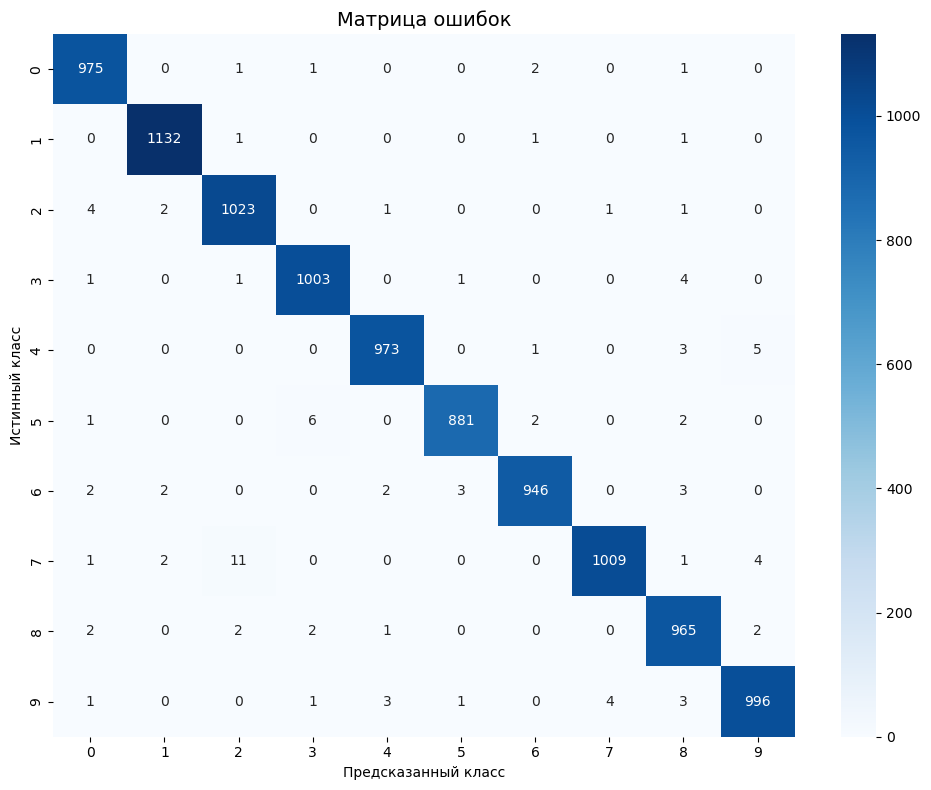

In [73]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in generate_batches(X_test_tensor, y_test_tensor, BATCH_SIZE):
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())

# Построение матрицы ошибок
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Матрица ошибок', fontsize=14)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

In [74]:
accuracy = 100 * (np.array(all_preds) == np.array(all_labels)).sum() / len(all_labels)
print(f"\nИтоговая точность на тестовой выборке: {accuracy:.2f}%")


Итоговая точность на тестовой выборке: 99.03%


In [75]:
torch.save(model.state_dict(), 'mnist_cnn_model.pth')
print("Модель сохранена как 'mnist_cnn_model.pth'")

Модель сохранена как 'mnist_cnn_model.pth'
